In [38]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. XAG

## 1.1 Data Cleaning

In [39]:
xag = pd.read_csv('data/COMMODITY/XAG_USD.csv', index_col=0)

print("raw data shape:", xag.shape)
print('\ncolumn names:', xag.columns.tolist())
print("\ndata types:\n", xag.dtypes)
print("\nfirt 5 rows:\n", xag.head())

raw data shape: (379053, 14)

column names: ['symbol', 'time', 'file_time', 'status', 'open_bid', 'high_bid', 'low_bid', 'close_bid', 'open_ask', 'high_ask', 'low_ask', 'close_ask', 'tick_cnt', 'time_frame']

data types:
 symbol         object
time           object
file_time       int64
status         object
open_bid      float64
high_bid      float64
low_bid       float64
close_bid     float64
open_ask      float64
high_ask      float64
low_ask       float64
close_ask     float64
tick_cnt        int64
time_frame     object
dtype: object

firt 5 rows:
     symbol                       time     file_time status  open_bid  \
0  XAG_USD  2025-01-01 23:04:00+00:00  202501012304    NaN   28.9575   
1  XAG_USD  2025-01-01 23:05:00+00:00  202501012305    NaN   28.9545   
2  XAG_USD  2025-01-01 23:06:00+00:00  202501012306    NaN   28.9620   
3  XAG_USD  2025-01-01 23:07:00+00:00  202501012307    NaN   28.9670   
4  XAG_USD  2025-01-01 23:08:00+00:00  202501012308    NaN   28.9670   

   high_

In [40]:
## Set `time` as the index
xag['time'] = pd.to_datetime(xag['time'])
xag.set_index('time', inplace=True)
print(f'[1] Set `time` as index')

## Drop rows with missing `status`
mask_valid = xag['status'].notna()
before = len(xag)
xag = xag[mask_valid].copy()
print(f'[2] Dropped rows with missing `status`: {before - len(xag)}')

## Drop unnecessary columns
xag = xag.drop(columns=['symbol', 'file_time', 'status', 'time_frame'])
print(f'[3] Dropped columns: symbol, file_time, status, time_frame')

## Define mid price for open, high, low, and close
xag['open'] = (xag['open_bid'] + xag['open_ask']) / 2  # Open
xag['high'] = (xag['high_bid'] + xag['high_ask']) / 2  # High
xag['low'] = (xag['low_bid'] + xag['low_ask']) / 2  # Low
xag['close'] = (xag['close_bid'] + xag['close_ask']) / 2  # Close
print(f'[4] Defined mid prices for: open, high, low, close')

print(f'\nData shape after preprocessing: {xag.shape}')
print(f'Time range: {xag.index.min().date()} ~ {xag.index.max().date()}')
print(f'Total trading days: {xag.index.normalize().nunique()}')

[1] Set `time` as index
[2] Dropped rows with missing `status`: 19253
[3] Dropped columns: symbol, file_time, status, time_frame
[4] Defined mid prices for: open, high, low, close

Data shape after preprocessing: (359800, 13)
Time range: 2025-01-21 ~ 2026-01-30
Total trading days: 320


=== Key features descriptive statistics ===
              open         high          low        close    tick_cnt
count  359800.0000  359800.0000  359800.0000  359800.0000  359800.000
mean       44.5996      44.6179      44.5810      44.5998      79.983
std        17.2123      17.2323      17.1914      17.2125      96.976
min        28.4365      28.4505      28.3445      28.4360       1.000
25%        33.0435      33.0515      33.0355      33.0439      28.000
50%        37.9075      37.9135      37.9008      37.9079      53.000
75%        49.0442      49.0632      49.0247      49.0451     100.000
max       121.6261     121.6736     121.5357     121.6059    1114.000


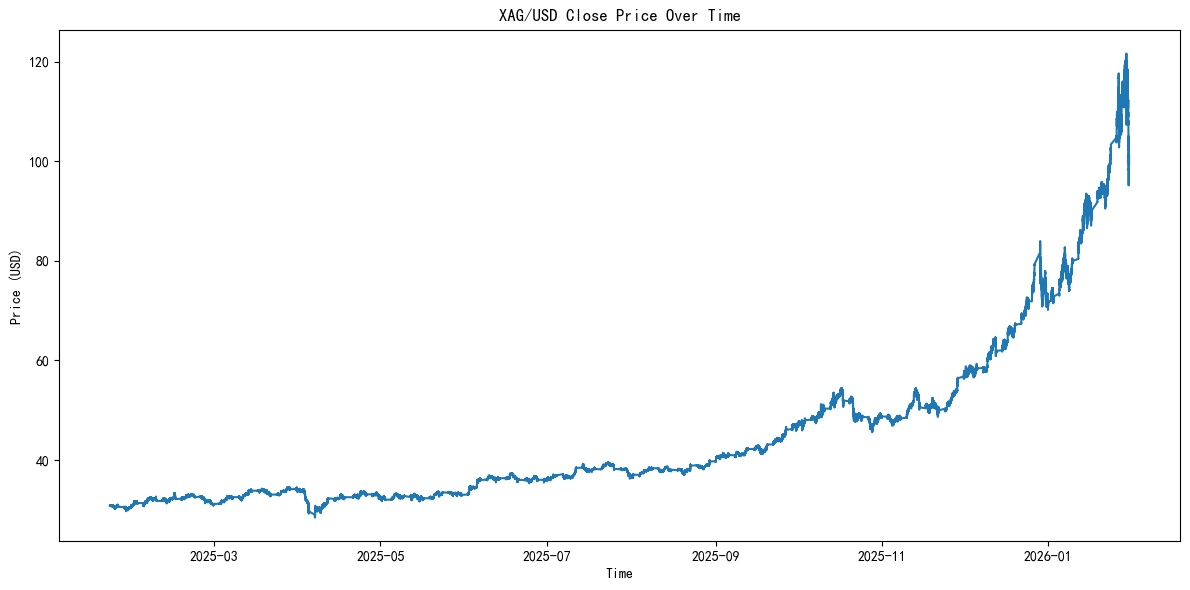

Data cleaning and EDA completed. Ready for feature engineering.


In [41]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

key_cols = ['open', 'high', 'low', 'close', 'tick_cnt']
print("=== Key features descriptive statistics ===")
print(xag[key_cols].describe().round(4))

## plot close price over time
plt.figure(figsize=(12, 6))
plt.plot(xag.index, xag['close'])
plt.title('XAG/USD Close Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()
print('Data cleaning and EDA completed. Ready for feature engineering.')

## 1.2 Feature Engineering (HFT factors)

### 1.2.1 Bid-Ask Spread & Order Book Pressure

In [42]:
# define rolling window size
n=10

In [43]:
# F01: Quoted Bid-Ask Spread
xag['QS']=xag['close_ask'] - xag['close_bid']
# The fundamental measure of market liquidity. A widening spread signals deteriorating liquidity and foreshadows short-term volatility increases; 
# a tightening spread is consistent with trending price action

# F02: Relative Bid-Ask Spread
xag['RS'] = (xag['close_ask'] - xag['close_bid']) / xag['close']
# Price-normalized spread enabling cross-sectional comparison. Negatively correlated with short-horizon returns; 
# widely used as a proxy for the liquidity risk premium.

# F03: Spread Change Z-Score
xag['SCZ'] = (xag['QS'] - xag['QS'].rolling(window=n).mean()) / xag['QS'].rolling(window=n).std()
# Captures sudden liquidity shocks. An abnormally wide spread often precedes large-order market impact; 
# used as a position-sizing or stop-loss trigger in execution models

# F04: Intrabar Spread Asymmetry
xag['ISA'] = (xag['high_ask'] - xag['high_bid']) - (xag['low_ask'] - xag['low_bid'])
# Measures within-bar spread imbalance between bid and ask sides. Positive values (ask-side expansion at highs) signal market stress; 
# negative values imply bid-side support.

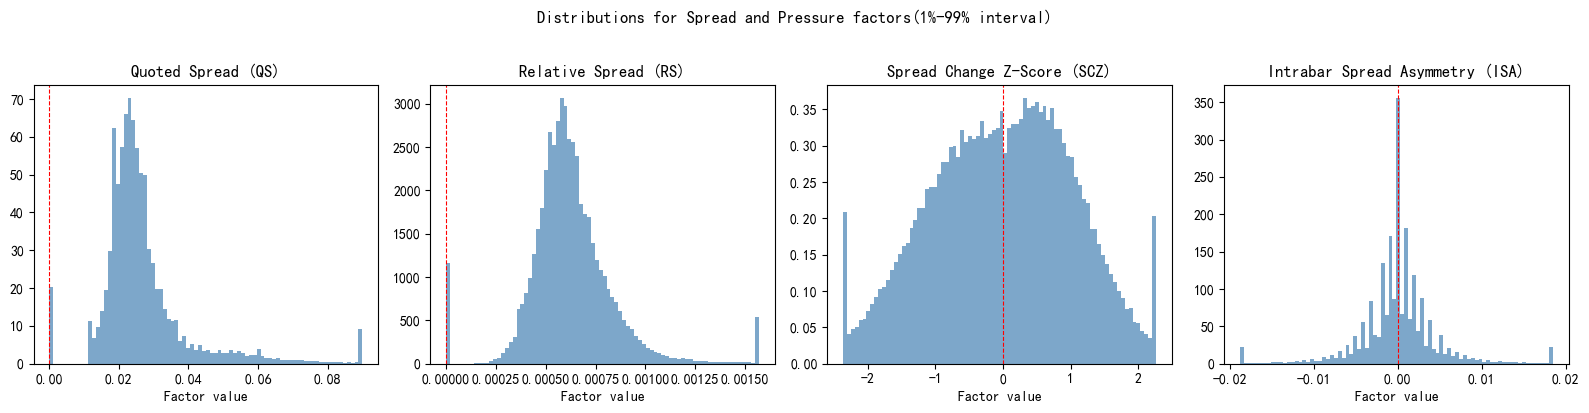

In [44]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['QS', 'RS', 'SCZ', 'ISA']
titles = ['Quoted Spread (QS)', 'Relative Spread (RS)', 'Spread Change Z-Score (SCZ)', 'Intrabar Spread Asymmetry (ISA)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Spread and Pressure factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.2 Price Momentum & Mean Reversion

In [45]:
#F05: Mid-Price Log Return
xag['MPR'] = np.log(xag['close'])-np.log(xag['close'].shift(n))
# Log return of the mid-price, eliminating single-sided quote noise. Short lookbacks (5–15 min) tend to mean-revert; 
# longer lookbacks (30–60 min) exhibit momentum persistence.

#F06: Intrabar Price Skewness
xag['IPS'] = (xag['close']-xag['open'])/(xag['high']-xag['low'])
# Analogous to Williams %R. Close near the bar's high (+1) signals bullish dominance; 
# near the low (−1) signals bearish dominance. Predictive of the next bar's direction.

#F07: Open-to-Close Gap
xag['OCG'] = (xag['open'] - xag['close'].shift(1)) / xag['close'].shift(1)
# Inter-bar mid-price gap between successive minutes. At high frequencies, gaps exhibit strong mean-reversion tendencies, 
# forming the basis of scalping and gap-fade strategies.

#F08: Range Expansion Ratio
xag['range'] = xag['high'] - xag['low']
xag['RER'] = xag['range'] / xag['range'].rolling(window=n).mean()
# RER > 1.5 often accompanies trend breakouts; RER < 0.5 indicates price compression (low-volatility regime), 
# frequently preceding explosive directional moves.

#F09: MA Spread / Crossover Signal
xag['MS'] = (xag['close'].rolling(window=5).mean()-xag['close'].rolling(window=20).mean())/xag['close'].rolling(window=20).mean()
# Measures short-term momentum relative to a longer-term trend. Positive values indicate bullish crossover;
# negative values indicate bearish crossover. The magnitude of MS can be used to gauge momentum strength.

#F10: Price Relative to MA20 (Mean-Reversion Signal)
xag['MR'] = (xag['close'] - xag['close'].rolling(window=20).mean()) / xag['close'].rolling(window=20).mean()
# Measures how far the current price deviates from its 20-minute moving average. Extreme positive values suggest overextension and potential mean-reversion;
# extreme negative values suggest overselling and potential mean-reversion.

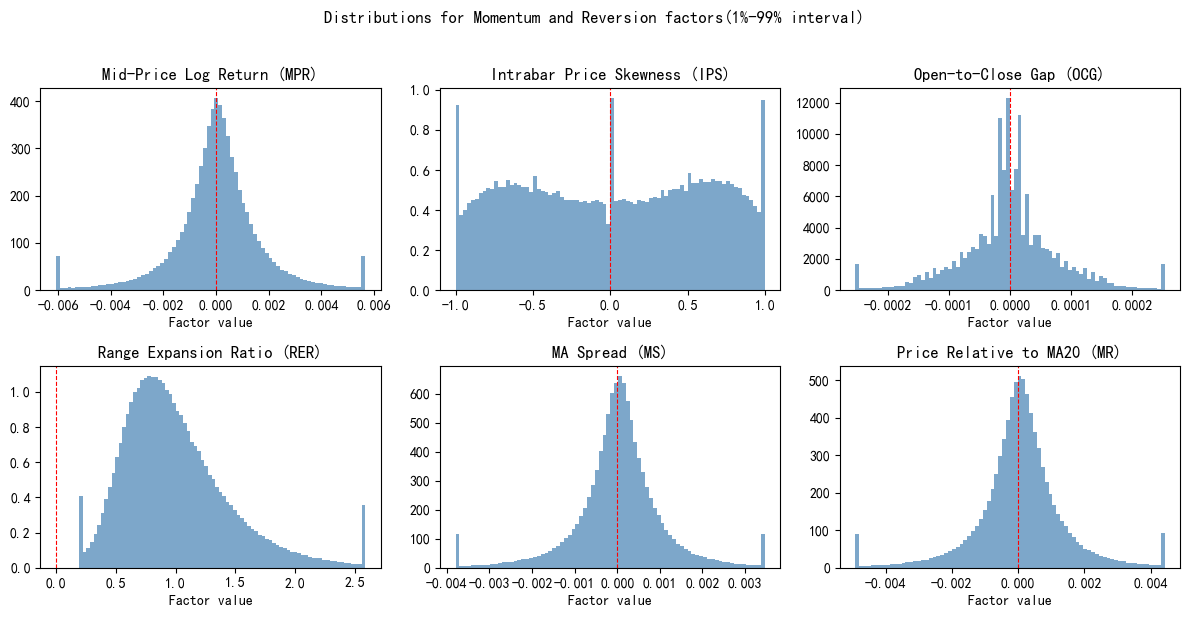

In [46]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
cols = ['MPR', 'IPS', 'OCG', 'RER', 'MS', 'MR']
titles = ['Mid-Price Log Return (MPR)', 'Intrabar Price Skewness (IPS)', 'Open-to-Close Gap (OCG)', 'Range Expansion Ratio (RER)', 'MA Spread (MS)', 'Price Relative to MA20 (MR)']

axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Momentum and Reversion factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.3 Volume Proxy & Trading Activity

In [47]:
#F11: Tick Density Ratio
xag['TDR'] = xag['tick_cnt'] / xag['tick_cnt'].rolling(window=n).mean()
# Normalizes current tick activity against its rolling average. TDR significantly above 1 indicates unusual order flow 
# — strongly associated with institutional activity and trend initiation.

#F12: Price-Tick Correlation
xag['delta']=xag['close'].diff()
xag['PTC'] = xag['delta'].rolling(window=n).corr(xag['tick_cnt'])
# Rolling correlation between mid-price changes and tick counts. Positive correlation confirms volume-price agreement (trend valid); 
# negative divergence signals potential reversal.

#F13: Tick-Weighted Mid Deviation
xag['amount'] = xag['tick_cnt'] * xag['close']
xag['TWAP'] = xag['amount'].rolling(window=n).sum() / xag['tick_cnt'].rolling(window=n).sum()
xag['TWMD'] = xag['close'] - xag['TWAP']
# VWAP analog using tick counts as volume proxy. Deviation from tick-weighted average is a mean-reversion signal; 
# persistent one-sided deviation indicates informed order flow.

#F14: Tick Acceleration
xag['TACC_R'] = (xag['tick_cnt'] - xag['tick_cnt'].shift(1))/xag['tick_cnt'].shift(1)
# First difference of tick counts — an activity acceleration indicator. Sustained tick acceleration is a hallmark of 
# algorithmic order slicing (TWAP/VWAP execution), predicting short-term price continuation.

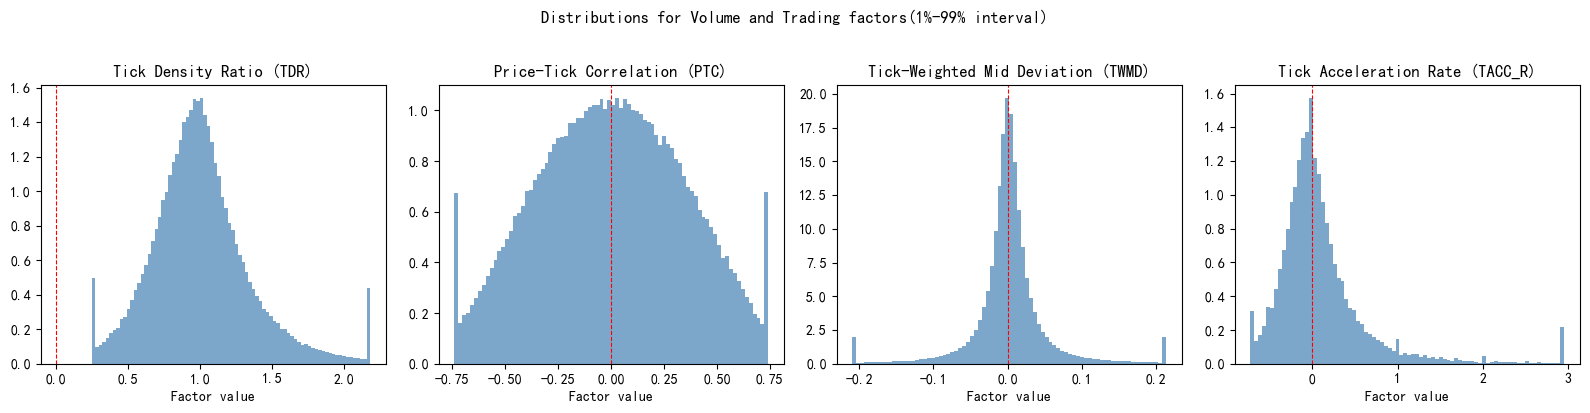

In [48]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['TDR', 'PTC', 'TWMD', 'TACC_R']
titles = ['Tick Density Ratio (TDR)', 'Price-Tick Correlation (PTC)', 'Tick-Weighted Mid Deviation (TWMD)', 'Tick Acceleration Rate (TACC_R)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Volume and Trading factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.4 Volatility & Risk Factors

In [49]:
## F15:Parkinson Volatility
xag['Parkinson']=np.log(xag['high']/xag['low'])**2
xag['PV'] = np.sqrt(xag['Parkinson'].rolling(window=n).mean()/(4*np.log(2)))
# Efficient range-based volatility estimator utilizing high and low prices. Reduces estimator variance by 
# ~5× versus close-to-close estimators — essential for noisy minute-level data.

# F16: Garman-Klass Volatility
xag['GKV'] = 0.5 * np.log((xag['high']/xag['low'])**2) - (2*np.log(2)-1) * np.log((xag['close']/xag['open'])**2)
# Optimal unbiased estimator exploiting all four OHLC prices. Compute independently on bid and ask series and average. 
# Outperforms Parkinson by further incorporating open-close information.

#F17: Volatility Regime Ratio
short = 5
long = 60
xag['VRR'] = xag['PV'].rolling(window=short).mean() / xag['PV'].rolling(window=long).mean()
# Short-to-long realized volatility ratio. VRR > 1 flags abnormal near-term turbulence (risk-off signal); 
# rising VRR trend often precedes large directional breaks. Central to regime detection.

#F18: Bid-Ask Volatility Asymmetry
xag['BVA'] = xag['close_bid'].rolling(window=n).std() / xag['close_ask'].rolling(window=n).std()
# Volatility differential between bid and ask quote series. Positive BVA (bid more volatile) implies elevated buy-side pressure; 
# negative implies sell-side dominance. Reflects structural order book imbalance.

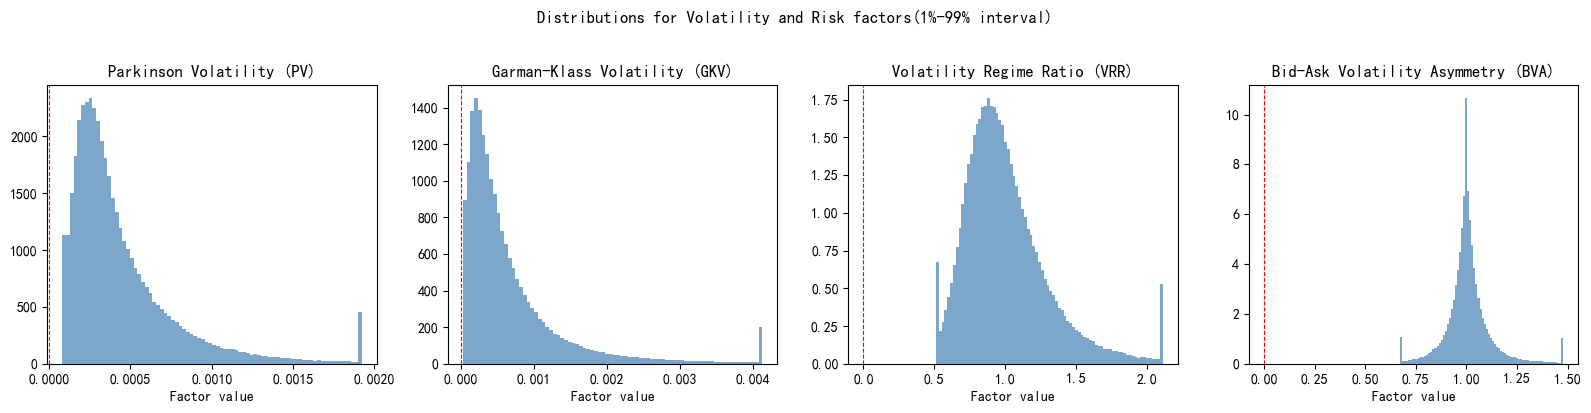

In [50]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['PV', 'GKV', 'VRR', 'BVA']
titles = ['Parkinson Volatility (PV)', 'Garman-Klass Volatility (GKV)', 'Volatility Regime Ratio (VRR)', 'Bid-Ask Volatility Asymmetry (BVA)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Volatility and Risk factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.5 Market Microstructure & Information Flow

In [51]:
#F19: Effective Spread Proxy
xag['ES']= 2*abs(xag['close']-xag['open'])
# Intrabar proxy for the effective spread — the actual transaction cost realized by traders. 
# When ES ≪ Quoted Spread, market efficiency is high. Divergence signals adverse selection and information asymmetry.

#F20: Roll Implied Spread
xag['delta_lag1']=xag['delta'].shift(1)
xag['cov'] = xag['delta'].rolling(window=n).cov(xag['delta_lag1'])
xag['RIS']= 2 * np.sqrt(np.maximum(-xag['cov'], 0))
# Classic Roll (1984) estimator that recovers the implicit spread from the serial covariance of mid-price changes. 
# Negative covariance is the microstructure fingerprint of the bid-ask bounce.

#F21: Kyle's Lambda (Price Impact)
xag['OF'] = np.sign(xag['delta']) * xag['tick_cnt']
cov_xy = xag['delta'].rolling(window=n).cov(xag['OF'])
var_x = xag['OF'].rolling(window=n).var()
xag['KL'] = cov_xy / var_x
# Kyle (1985) price impact coefficient estimated with tick counts as an order flow proxy. 
# λ̂ measures per-unit flow impact on price — a direct gauge of information asymmetry and market depth.

#F22: Amihud Illiquidity Ratio
xag['ILLIQ'] = abs(xag['delta']) / xag['tick_cnt']
xag['AIR'] = xag['ILLIQ'].rolling(window=n).mean()
# Amihud (2002) illiquidity ratio adapted to minute bars, with tick count replacing dollar volume. 
# Higher AIR means greater price impact per unit of order flow — illiquidity risk premium proxy.

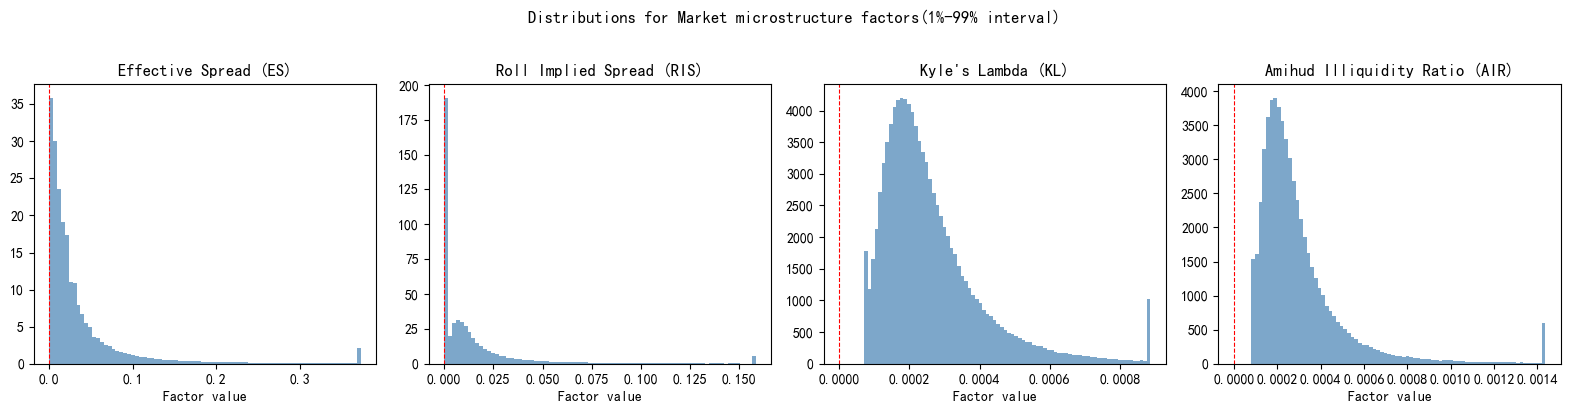

In [52]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['ES', 'RIS', 'KL', 'AIR']
titles = ['Effective Spread (ES)', 'Roll Implied Spread (RIS)', "Kyle's Lambda (KL)", 'Amihud Illiquidity Ratio (AIR)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Market microstructure factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

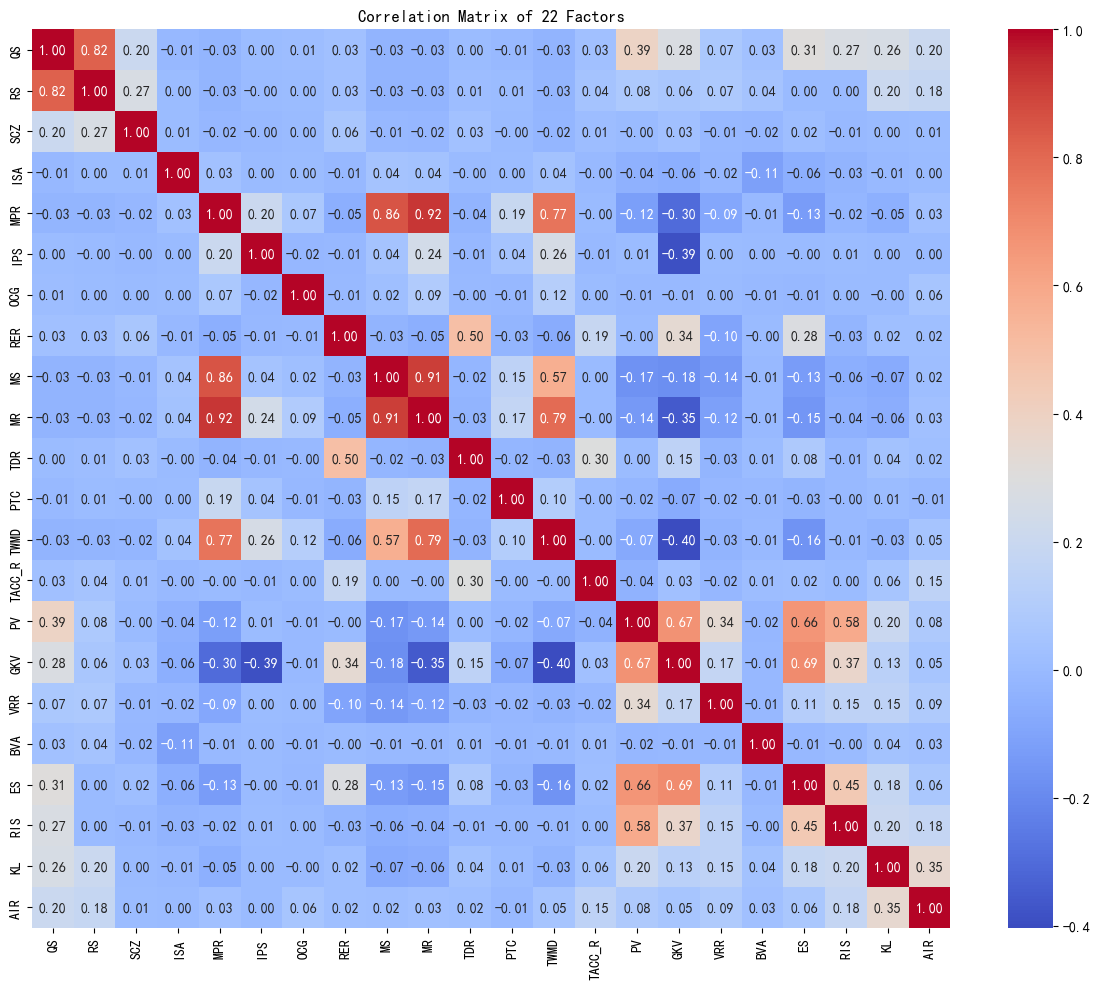

In [53]:
# factor correlation heatmap
plt.figure(figsize=(12, 10))
BASE_FACTORS = ['QS', 'RS', 'SCZ', 'ISA', 'MPR', 'IPS', 'OCG', 'RER', 'MS', 'MR', 'TDR', 'PTC', 'TWMD', 'TACC_R', 'PV', 'GKV', 'VRR', 'BVA', 'ES', 'RIS', 'KL', 'AIR']
corr_matrix = xag[BASE_FACTORS].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of 22 Factors')
plt.tight_layout()
plt.show()


### 1.2.6 Factor Expansion

In [54]:
# Factor expansion: add lag terms, difference terms, rolling statistics, time features, and regime features
def add_factor_transforms(df, factor_cols, lags=(1, 5, 20)):
    out = df.copy()

    for f in factor_cols:
        for l in lags:
            out[f"{f}_lag{l}"] = out[f].shift(l)          # 1) Lag features: capture persistence
            out[f"{f}_ret{l}"] = out[f].pct_change(l)     # 2) Change features: capture factor momentum
        
    return out

def add_time_features(df):
    out = df.copy()
    idx = out.index

    # 3) Intraday time features
    # Cyclical encoding
    out["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    out["minute_sin"] = np.sin(2 * np.pi * idx.minute / 60)
    out["minute_cos"] = np.cos(2 * np.pi * idx.minute / 60)

    # Session flags
    out["is_asia_session"] = ((idx.hour >= 0) & (idx.hour < 8)).astype(int)
    out["is_europe_session"] = ((idx.hour >= 8) & (idx.hour < 16)).astype(int)
    out["is_us_session"] = ((idx.hour >= 13) & (idx.hour < 21)).astype(int)

    return out

def add_regime_features(df):
    out = df.copy()

    # 4) Volatility regime features
    ret1 = out["close"].pct_change(1)
    out["rv20"] = ret1.rolling(20).std()

    q_low = out["rv20"].rolling(500).quantile(0.33)
    q_high = out["rv20"].rolling(500).quantile(0.66)

    out["regime_low_vol"] = (out["rv20"] <= q_low).astype(int)
    out["regime_high_vol"] = (out["rv20"] >= q_high).astype(int)
    out["regime_mid_vol"] = 1 - out["regime_low_vol"] - out["regime_high_vol"]

    return out

# Apply feature expansion
xag = add_factor_transforms(xag, BASE_FACTORS, lags=(1, 5, 20))
xag = add_time_features(xag)
xag = add_regime_features(xag)

FACTORS_EXPANDED = BASE_FACTORS+xag.columns.tolist()[-143:]
FACTORS_EXPANDED = list(filter(lambda x: x != "rv20", FACTORS_EXPANDED))

print(f"Original factor count: {len(BASE_FACTORS)}")
print(f"Expanded factor count: {len(FACTORS_EXPANDED)}")
print("Feature expansion completed")

Original factor count: 22
Expanded factor count: 164
Feature expansion completed


## 1.3 Factor testing

In [55]:
# Calculate forward returns for 5min, 10min, 20min, and 50min
xag['ret_5m'] = (xag['close'].shift(-5) - xag['close']) / xag['close']
xag['ret_10m'] = (xag['close'].shift(-10) - xag['close']) / xag['close']
xag['ret_20m'] = (xag['close'].shift(-20) - xag['close']) / xag['close']
xag['ret_50m'] = (xag['close'].shift(-50) - xag['close']) / xag['close']


## Drop rows with NaN values
xag = xag.dropna(subset=['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m'])
print("Forward return calculation completed")
print(xag[['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m']].describe().round(4))

Forward return calculation completed
            ret_5m      ret_10m      ret_20m      ret_50m
count  359750.0000  359750.0000  359750.0000  359750.0000
mean        0.0000       0.0000       0.0001       0.0002
std         0.0015       0.0021       0.0030       0.0047
min        -0.0549      -0.0632      -0.0834      -0.1103
25%        -0.0005      -0.0007      -0.0010      -0.0014
50%         0.0000       0.0001       0.0001       0.0002
75%         0.0006       0.0008       0.0012       0.0019
max         0.0394       0.0438       0.0590       0.0644


In [56]:
# ──────────────────────────────────────────────────────────────────
# IC testing：every n-minute period Pearson IC 和 Rank IC
# ──────────────────────────────────────────────────────────────────
RET_HORIZONS = ['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m']

def compute_ic_series(df, factor_col, ret_col, n):
    """every n-minute period compute Pearson IC and Rank IC(Spearman)"""
    ic_list = []
    for i in range(0, len(df) - n, n):
        factor_values = df[factor_col].iloc[i:i+n]
        returns = df[ret_col].iloc[i:i+n]
        if len(factor_values) > 1 and len(returns) > 1:
            pearson_ic = factor_values.corr(returns)
            rank_ic, _ = spearmanr(factor_values, returns)
            ic_list.append({'time': df.index[i], 'IC': pearson_ic, 'RankIC': rank_ic})
    return pd.DataFrame(ic_list).set_index("time")
    
TEST_FACTORS = BASE_FACTORS + ["hour_sin", "hour_cos", "minute_sin", "minute_cos", "is_asia_session", "is_europe_session", "is_us_session", "regime_low_vol", "regime_high_vol", "regime_mid_vol"]
period = 600

# Compute all factors'IC to 5-minute future return
print("=== IC testing result summary (ret_5m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_5m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_5m) ===

QS                   | IC=+0.0070  IC_IR=+0.096  RankIC=+0.0064  RankIR=+0.093  Positive IC percentage=53.6%
RS                   | IC=+0.0101  IC_IR=+0.138  RankIC=+0.0151  RankIR=+0.220  Positive IC percentage=55.1%
SCZ                  | IC=+0.0008  IC_IR=+0.015  RankIC=-0.0000  RankIR=-0.001  Positive IC percentage=47.2%
ISA                  | IC=+0.0024  IC_IR=+0.045  RankIC=+0.0044  RankIR=+0.090  Positive IC percentage=49.4%
MPR                  | IC=-0.0403  IC_IR=-0.371  RankIC=-0.0460  RankIR=-0.523  Positive IC percentage=33.7%
IPS                  | IC=-0.0087  IC_IR=-0.187  RankIC=-0.0187  RankIR=-0.417  Positive IC percentage=40.9%
OCG                  | IC=-0.0049  IC_IR=-0.098  RankIC=-0.0049  RankIR=-0.118  Positive IC percentage=45.9%
RER                  | IC=+0.0044  IC_IR=+0.081  RankIC=+0.0043  RankIR=+0.091  Positive IC percentage=54.4%
MS                   | IC=-0.0418  IC_IR=-0.389  RankIC=-0.0467  RankIR=-0.522  Posi

In [57]:
# Compute all factors'IC to 10-minute future return
print("=== IC testing result summary (ret_10m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_10m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_10m) ===

QS                   | IC=+0.0083  IC_IR=+0.093  RankIC=+0.0080  RankIR=+0.093  Positive IC percentage=52.1%
RS                   | IC=+0.0126  IC_IR=+0.140  RankIC=+0.0195  RankIR=+0.226  Positive IC percentage=53.8%
SCZ                  | IC=+0.0031  IC_IR=+0.054  RankIC=+0.0023  RankIR=+0.039  Positive IC percentage=47.1%
ISA                  | IC=+0.0032  IC_IR=+0.053  RankIC=+0.0047  RankIR=+0.084  Positive IC percentage=50.1%
MPR                  | IC=-0.0500  IC_IR=-0.391  RankIC=-0.0546  RankIR=-0.516  Positive IC percentage=32.7%
IPS                  | IC=-0.0118  IC_IR=-0.258  RankIC=-0.0220  RankIR=-0.517  Positive IC percentage=39.6%
OCG                  | IC=-0.0076  IC_IR=-0.152  RankIC=-0.0078  RankIR=-0.171  Positive IC percentage=42.7%
RER                  | IC=+0.0037  IC_IR=+0.075  RankIC=+0.0034  RankIR=+0.076  Positive IC percentage=53.6%
MS                   | IC=-0.0540  IC_IR=-0.402  RankIC=-0.0582  RankIR=-0.503  Pos

In [58]:
# Compute all factors'IC to 20-minute future return
print("=== IC testing result summary (ret_20m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_20m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_20m) ===

QS                   | IC=+0.0067  IC_IR=+0.060  RankIC=+0.0065  RankIR=+0.059  Positive IC percentage=51.4%
RS                   | IC=+0.0127  IC_IR=+0.112  RankIC=+0.0215  RankIR=+0.193  Positive IC percentage=53.6%
SCZ                  | IC=+0.0036  IC_IR=+0.072  RankIC=+0.0017  RankIR=+0.033  Positive IC percentage=48.9%
ISA                  | IC=+0.0032  IC_IR=+0.046  RankIC=+0.0044  RankIR=+0.070  Positive IC percentage=50.8%
MPR                  | IC=-0.0652  IC_IR=-0.480  RankIC=-0.0666  RankIR=-0.572  Positive IC percentage=29.7%
IPS                  | IC=-0.0166  IC_IR=-0.371  RankIC=-0.0243  RankIR=-0.576  Positive IC percentage=33.9%
OCG                  | IC=-0.0072  IC_IR=-0.144  RankIC=-0.0090  RankIR=-0.189  Positive IC percentage=42.1%
RER                  | IC=+0.0037  IC_IR=+0.088  RankIC=+0.0039  RankIR=+0.100  Positive IC percentage=53.1%
MS                   | IC=-0.0692  IC_IR=-0.451  RankIC=-0.0691  RankIR=-0.511  Pos

In [59]:
# Compute all factors'IC to 50-minute future return
print("=== IC testing result summary (ret_50m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_50m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_50m) ===

QS                   | IC=+0.0052  IC_IR=+0.035  RankIC=+0.0070  RankIR=+0.047  Positive IC percentage=52.1%
RS                   | IC=+0.0139  IC_IR=+0.095  RankIC=+0.0275  RankIR=+0.185  Positive IC percentage=53.3%
SCZ                  | IC=+0.0037  IC_IR=+0.092  RankIC=+0.0045  RankIR=+0.109  Positive IC percentage=50.9%
ISA                  | IC=+0.0012  IC_IR=+0.015  RankIC=+0.0031  RankIR=+0.040  Positive IC percentage=47.6%
MPR                  | IC=-0.0807  IC_IR=-0.621  RankIC=-0.0767  RankIR=-0.656  Positive IC percentage=25.7%
IPS                  | IC=-0.0201  IC_IR=-0.481  RankIC=-0.0252  RankIR=-0.632  Positive IC percentage=30.2%
OCG                  | IC=-0.0059  IC_IR=-0.120  RankIC=-0.0068  RankIR=-0.138  Positive IC percentage=44.2%
RER                  | IC=+0.0033  IC_IR=+0.099  RankIC=+0.0040  RankIR=+0.125  Positive IC percentage=51.8%
MS                   | IC=-0.0919  IC_IR=-0.599  RankIC=-0.0853  RankIR=-0.605  Pos

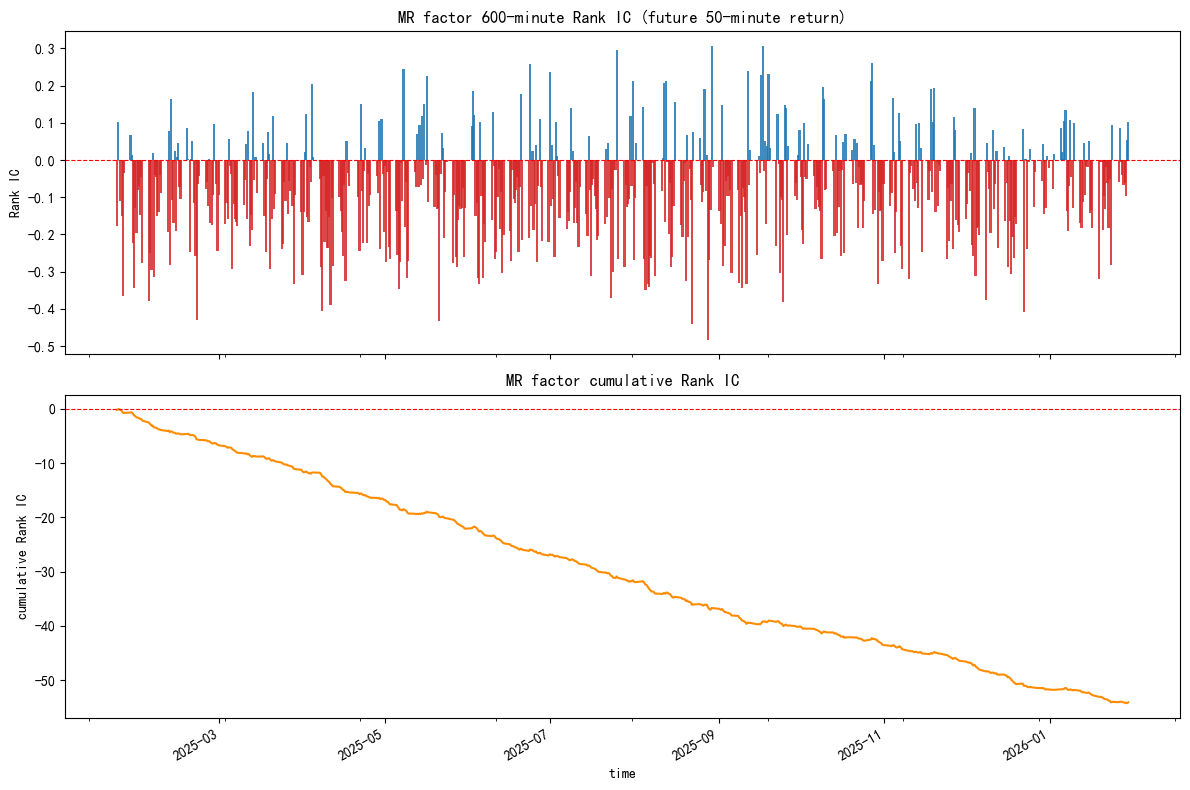

In [60]:
# ──────────────────────────────────────────────────────────────────
# MR factor's Rank IC and cumulative value
# ──────────────────────────────────────────────────────────────────
ic_mr_50min = compute_ic_series(xag, 'MR', 'ret_50m', period)

colors = ['#d62728' if v < 0 else '#1f77b4' for v in ic_mr_50min['RankIC']]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].bar(ic_mr_50min.index, ic_mr_50min['RankIC'], width=0.8, color=colors, alpha=0.85)
axes[0].axhline(0, color='red', lw=0.8, ls='--')
axes[0].set_title(f'MR factor {period}-minute Rank IC (future 50-minute return)')
axes[0].set_ylabel('Rank IC')

ic_mr_50min['RankIC'].cumsum().plot(ax=axes[1], color='darkorange')
axes[1].axhline(0, color='red', lw=0.8, ls='--')
axes[1].set_title('MR factor cumulative Rank IC')
axes[1].set_ylabel('cumulative Rank IC')
axes[1].set_xlabel('time')

plt.tight_layout()
plt.show()

## 1.4 Model Fitting

### 1.4.1 Classification models

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, matthews_corrcoef, balanced_accuracy_score
)

def clean_X_train_val(X_train_df, X_val_df):
    # 1) inf -> nan
    X_train = X_train_df.replace([np.inf, -np.inf], np.nan).copy()
    X_val = X_val_df.replace([np.inf, -np.inf], np.nan).copy()

    # 2) use training set's 1% and 99% quantiles to clip extreme values in both training and validation sets
    q_low = X_train.quantile(0.01)
    q_high = X_train.quantile(0.99)
    X_train = X_train.clip(lower=q_low, upper=q_high, axis=1)
    X_val = X_val.clip(lower=q_low, upper=q_high, axis=1)

    # 3) use training set's median to fill missing values in both training and validation sets
    med = X_train.median()
    X_train = X_train.fillna(med)
    X_val = X_val.fillna(med)

    # 4) after clipping and filling, if there are still nan values, replace them with 0
    X_train = X_train.replace(np.nan, 0.0)
    X_val = X_val.replace(np.nan, 0.0)

    return X_train.values, X_val.values

def rolling_backtest(
    df,
    factor_cols,
    ret_col,
    target_col,
    model,
    training_size,
    embargo,
    validation_size,
    step_size,
    use_pca=False,
    pca_keep=0.8
):
    """Rolling window backtest for classification model"""
    classification_metrics = []
    
    for start in range(0, len(df) - training_size - embargo - validation_size+1, step_size):
        train_start = start
        train_end = start + training_size
        val_start = train_end + embargo
        val_end = val_start + validation_size
        
        train_df = df.iloc[train_start:train_end].copy()
        val_df = df.iloc[val_start:val_end].copy()
        # use Tercile of the return_col in the training set 
        # to generate the classification target(1: positive return, 0: random noise, -1: negative return)
        q1, q2 = train_df[ret_col].quantile([1/3, 2/3])
        bins = [-np.inf, q1, q2, np.inf]
        labels = [0, 1, 2]  # 0: down, 1: noise, 2: up
        train_df[target_col] = pd.cut(train_df[ret_col], bins=bins, labels=labels, include_lowest=True)
        val_df[target_col] = pd.cut(val_df[ret_col], bins=bins, labels=labels, include_lowest=True)


        X_train_df = train_df[factor_cols]
        X_val_df = val_df[factor_cols]
        y_train = train_df[target_col].values
        y_val = val_df[target_col].values

        # Step 1: data cleaning for features
        X_train, X_val = clean_X_train_val(X_train_df, X_val_df)

        # Step 2: standardize features using training set's parameters
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # Step 3(Optional): dimensionality reduction with PCA (fit on training set only)
        if use_pca:
            pca = PCA(n_components=pca_keep, svd_solver='full')  # retain specified percentage of the variance
            X_train = pca.fit_transform(X_train)
            X_val = pca.transform(X_val)

        model.fit(X_train, y_train)
        pred_proba = model.predict_proba(X_val)  # predicted probabilities for each class
        pred = model.predict(X_val)  # predicted class labels
        
        classification_metrics.append({
            'time': val_df.index[0],
            'accuracy': accuracy_score(y_val, pred),
            'precision': precision_score(y_val, pred, average='macro', zero_division=0),
            'recall': recall_score(y_val, pred, average='macro', zero_division=0),
            'f1': f1_score(y_val, pred, average='macro', zero_division=0),
            'log_loss': log_loss(y_val, pred_proba, labels=labels),
        })
    
    return pd.DataFrame(classification_metrics).set_index('time')

# employ rolling window for training and validation
training_size = 1800  # training window size
validation_size = 200  # validation window size
step_size = 1800  # step size for rolling window

#### 1.4.1.1 Logistic Regression

In [62]:
# ──────────────────────────────────────────────────────────────────
# Logistic regression backtest using all factors to predict n-minute future trend
# ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
## Create different logistic regression models(plain, lasso, ridge, elasticnet) for comparison
logistic_models={
    'LR_plain': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'LR_lasso': LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
    'LR_ridge': LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    'LR_elasticnet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000, random_state=42)
}

# Summarize metrics for logistic models on 5-minute future trend
print("=== Logistic Regression metrics summary (trend_5m) ===\n")
RET_COL = 'ret_5m'
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_5m) ===

LR_plain (without PCA)         | Accuracy=0.3735  Precision=0.3556  Recall=0.3516  F1=0.3318  Log Loss=1.2729  
LR_plain (with PCA)            | Accuracy=0.3906  Precision=0.3624  Recall=0.3583  F1=0.3384  Log Loss=1.1181  
LR_lasso (without PCA)         | Accuracy=0.3760  Precision=0.3563  Recall=0.3528  F1=0.3331  Log Loss=1.2417  
LR_lasso (with PCA)            | Accuracy=0.3907  Precision=0.3628  Recall=0.3581  F1=0.3380  Log Loss=1.1160  
LR_ridge (without PCA)         | Accuracy=0.3735  Precision=0.3556  Recall=0.3516  F1=0.3318  Log Loss=1.2729  
LR_ridge (with PCA)            | Accuracy=0.3906  Precision=0.3624  Recall=0.3583  F1=0.3384  Log Loss=1.1181  
LR_elasticnet (without PCA)    | Accuracy=0.3743  Precision=0.3563  Recall=0.3518  F1=0.3320  Log Loss=1.2551  
LR_elasticnet (with PCA)       | Accuracy=0.3907  Precision=0.3630  Recall=0.3583  F1=0.3384  Log Loss=1.1170  


In [63]:
# Summarize metrics for logistic models on 10-minute future trend
print("=== Logistic Regression metrics summary (trend_10m) ===\n")
RET_COL = 'ret_10m'
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_10m) ===

LR_plain (without PCA)         | Accuracy=0.3708  Precision=0.3518  Recall=0.3518  F1=0.3245  Log Loss=1.3571  
LR_plain (with PCA)            | Accuracy=0.3847  Precision=0.3581  Recall=0.3554  F1=0.3306  Log Loss=1.1430  
LR_lasso (without PCA)         | Accuracy=0.3719  Precision=0.3539  Recall=0.3524  F1=0.3256  Log Loss=1.3218  
LR_lasso (with PCA)            | Accuracy=0.3853  Precision=0.3592  Recall=0.3559  F1=0.3310  Log Loss=1.1403  
LR_ridge (without PCA)         | Accuracy=0.3708  Precision=0.3518  Recall=0.3518  F1=0.3245  Log Loss=1.3571  
LR_ridge (with PCA)            | Accuracy=0.3847  Precision=0.3581  Recall=0.3554  F1=0.3306  Log Loss=1.1430  
LR_elasticnet (without PCA)    | Accuracy=0.3725  Precision=0.3546  Recall=0.3530  F1=0.3261  Log Loss=1.3368  
LR_elasticnet (with PCA)       | Accuracy=0.3848  Precision=0.3585  Recall=0.3555  F1=0.3306  Log Loss=1.1416  


In [64]:
# Summarize metrics for logistic models on 20-minute future trend
print("=== Logistic Regression metrics summary (trend_20m) ===\n")
RET_COL = 'ret_20m'
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_20m) ===

LR_plain (without PCA)         | Accuracy=0.3710  Precision=0.3538  Recall=0.3552  F1=0.3197  Log Loss=1.4765  
LR_plain (with PCA)            | Accuracy=0.3724  Precision=0.3507  Recall=0.3497  F1=0.3174  Log Loss=1.1754  
LR_lasso (without PCA)         | Accuracy=0.3707  Precision=0.3513  Recall=0.3542  F1=0.3182  Log Loss=1.4392  
LR_lasso (with PCA)            | Accuracy=0.3729  Precision=0.3510  Recall=0.3501  F1=0.3177  Log Loss=1.1722  
LR_ridge (without PCA)         | Accuracy=0.3710  Precision=0.3538  Recall=0.3552  F1=0.3197  Log Loss=1.4765  
LR_ridge (with PCA)            | Accuracy=0.3724  Precision=0.3507  Recall=0.3497  F1=0.3174  Log Loss=1.1754  
LR_elasticnet (without PCA)    | Accuracy=0.3716  Precision=0.3529  Recall=0.3550  F1=0.3194  Log Loss=1.4540  
LR_elasticnet (with PCA)       | Accuracy=0.3728  Precision=0.3510  Recall=0.3500  F1=0.3176  Log Loss=1.1738  


In [65]:
# Summarize metrics for logistic models on 50-minute future trend
print("=== Logistic Regression metrics summary (trend_50m) ===\n")
RET_COL = 'ret_50m'
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in logistic_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_50m) ===

LR_plain (without PCA)         | Accuracy=0.3611  Precision=0.3564  Recall=0.3546  F1=0.2903  Log Loss=1.7290  
LR_plain (with PCA)            | Accuracy=0.3675  Precision=0.3538  Recall=0.3550  F1=0.2977  Log Loss=1.2255  
LR_lasso (without PCA)         | Accuracy=0.3612  Precision=0.3591  Recall=0.3544  F1=0.2887  Log Loss=1.7026  
LR_lasso (with PCA)            | Accuracy=0.3678  Precision=0.3537  Recall=0.3557  F1=0.2976  Log Loss=1.2212  
LR_ridge (without PCA)         | Accuracy=0.3611  Precision=0.3564  Recall=0.3546  F1=0.2903  Log Loss=1.7290  
LR_ridge (with PCA)            | Accuracy=0.3675  Precision=0.3538  Recall=0.3550  F1=0.2977  Log Loss=1.2255  
LR_elasticnet (without PCA)    | Accuracy=0.3611  Precision=0.3572  Recall=0.3539  F1=0.2891  Log Loss=1.7091  
LR_elasticnet (with PCA)       | Accuracy=0.3678  Precision=0.3540  Recall=0.3559  F1=0.2978  Log Loss=1.2233  


#### 1.4.1.2 Generative Models

In [66]:
# test generative classifiers (Naive Bayes, LDA, QDA, KNN) on future trend prediction
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

generative_models = {
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),  # add small regularization to avoid singular covariance
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Summarize metrics for generative models on 5-minute future trend
print("=== Generative model metrics summary (trend_5m) ===\n")
RET_COL = 'ret_5m'
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Generative model metrics summary (trend_5m) ===

Naive Bayes (without PCA)      | Accuracy=0.3987  Precision=0.3652  Recall=0.3597  F1=0.3256  Log Loss=5.3446  
Naive Bayes (with PCA)         | Accuracy=0.3748  Precision=0.3518  Recall=0.3509  F1=0.3293  Log Loss=1.2417  
LDA (without PCA)              | Accuracy=0.3689  Precision=0.3602  Recall=0.3528  F1=0.3199  Log Loss=1.3540  
LDA (with PCA)                 | Accuracy=0.3908  Precision=0.3638  Recall=0.3586  F1=0.3380  Log Loss=1.1192  
QDA (without PCA)              | Accuracy=0.3770  Precision=0.3500  Recall=0.3493  F1=0.3337  Log Loss=5.2860  
QDA (with PCA)                 | Accuracy=0.3743  Precision=0.3504  Recall=0.3496  F1=0.3372  Log Loss=2.4066  
KNN (without PCA)              | Accuracy=0.3530  Precision=0.3436  Recall=0.3412  F1=0.3258  Log Loss=6.1748  
KNN (with PCA)                 | Accuracy=0.3541  Precision=0.3430  Recall=0.3420  F1=0.3260  Log Loss=6.2817  


In [67]:
# Summarize metrics for generative models on 10-minute future trend
print("=== Generative model metrics summary (trend_10m) ===\n")
RET_COL = 'ret_10m'
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Generative model metrics summary (trend_10m) ===

Naive Bayes (without PCA)      | Accuracy=0.3954  Precision=0.3639  Recall=0.3612  F1=0.3235  Log Loss=5.6139  
Naive Bayes (with PCA)         | Accuracy=0.3762  Precision=0.3555  Recall=0.3541  F1=0.3282  Log Loss=1.2707  
LDA (without PCA)              | Accuracy=0.3698  Precision=0.3594  Recall=0.3570  F1=0.3142  Log Loss=1.4874  
LDA (with PCA)                 | Accuracy=0.3843  Precision=0.3567  Recall=0.3555  F1=0.3298  Log Loss=1.1431  
QDA (without PCA)              | Accuracy=0.3777  Precision=0.3533  Recall=0.3534  F1=0.3323  Log Loss=5.6746  
QDA (with PCA)                 | Accuracy=0.3717  Precision=0.3493  Recall=0.3499  F1=0.3326  Log Loss=2.5910  
KNN (without PCA)              | Accuracy=0.3515  Precision=0.3435  Recall=0.3421  F1=0.3225  Log Loss=6.6110  
KNN (with PCA)                 | Accuracy=0.3526  Precision=0.3458  Recall=0.3431  F1=0.3249  Log Loss=6.8042  


In [68]:
# Summarize metrics for generative models on 20-minute future trend
print("=== Generative model metrics summary (trend_20m) ===\n")
RET_COL = 'ret_20m'
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Generative model metrics summary (trend_20m) ===

Naive Bayes (without PCA)      | Accuracy=0.3886  Precision=0.3500  Recall=0.3563  F1=0.3127  Log Loss=5.9670  
Naive Bayes (with PCA)         | Accuracy=0.3687  Precision=0.3534  Recall=0.3515  F1=0.3198  Log Loss=1.3230  
LDA (without PCA)              | Accuracy=0.3683  Precision=0.3540  Recall=0.3599  F1=0.3020  Log Loss=1.6999  
LDA (with PCA)                 | Accuracy=0.3733  Precision=0.3500  Recall=0.3504  F1=0.3169  Log Loss=1.1764  
QDA (without PCA)              | Accuracy=0.3715  Precision=0.3480  Recall=0.3478  F1=0.3217  Log Loss=6.1211  
QDA (with PCA)                 | Accuracy=0.3656  Precision=0.3440  Recall=0.3441  F1=0.3209  Log Loss=2.8537  
KNN (without PCA)              | Accuracy=0.3495  Precision=0.3480  Recall=0.3444  F1=0.3165  Log Loss=7.0167  
KNN (with PCA)                 | Accuracy=0.3502  Precision=0.3452  Recall=0.3433  F1=0.3166  Log Loss=7.1770  


In [69]:
# Summarize metrics for generative models on 50-minute future trend
print("=== Generative model metrics summary (trend_50m) ===\n")
RET_COL = 'ret_50m'
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in generative_models.items():
    for i in range(2):
        df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=i,pca_keep=0.8)
        acc_mean = df_metric['accuracy'].mean()
        prec_mean = df_metric['precision'].mean()
        rec_mean = df_metric['recall'].mean()
        f1_mean = df_metric['f1'].mean()
        log_loss_mean = df_metric['log_loss'].mean()
        pca_tag = "(without PCA)" if i == 0 else "(with PCA)  "
        model_name = f"{name} {pca_tag}"

        print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
              f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Generative model metrics summary (trend_50m) ===

Naive Bayes (without PCA)      | Accuracy=0.3710  Precision=0.3545  Recall=0.3532  F1=0.2946  Log Loss=6.8420  
Naive Bayes (with PCA)         | Accuracy=0.3597  Precision=0.3499  Recall=0.3500  F1=0.2982  Log Loss=1.4109  
LDA (without PCA)              | Accuracy=0.3663  Precision=0.3543  Recall=0.3680  F1=0.2819  Log Loss=2.1528  
LDA (with PCA)                 | Accuracy=0.3683  Precision=0.3519  Recall=0.3559  F1=0.2966  Log Loss=1.2221  
QDA (without PCA)              | Accuracy=0.3622  Precision=0.3486  Recall=0.3458  F1=0.3029  Log Loss=6.9214  
QDA (with PCA)                 | Accuracy=0.3610  Precision=0.3509  Recall=0.3484  F1=0.3080  Log Loss=3.2165  
KNN (without PCA)              | Accuracy=0.3529  Precision=0.3447  Recall=0.3449  F1=0.3046  Log Loss=7.1979  
KNN (with PCA)                 | Accuracy=0.3553  Precision=0.3474  Recall=0.3458  F1=0.3061  Log Loss=7.5173  


#### 1.4.1.3 Tree-based models

In [70]:
# test tree-based classifiers (Bagging, Random Forest, Gradient Boosting, XGBoost) on future trend prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

tree_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=8, random_state=42),
        n_estimators=100,
        bootstrap=True,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=8,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [71]:
# Summarize metrics for tree-based models on 5-minute future trend
print("=== Tree-based model metrics summary (trend_5m) ===\n")
RET_COL = 'ret_5m'
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Tree-based model metrics summary (trend_5m) ===

Bagging              | Accuracy=0.4043  Precision=0.3575  Recall=0.3602  F1=0.3266  Log Loss=1.0828  
Random Forest        | Accuracy=0.4118  Precision=0.3665  Recall=0.3649  F1=0.3289  Log Loss=1.0753  
Gradient Boosting    | Accuracy=0.3891  Precision=0.3637  Recall=0.3584  F1=0.3399  Log Loss=1.1240  
XGBoost              | Accuracy=0.3937  Precision=0.3666  Recall=0.3603  F1=0.3403  Log Loss=1.1091  


In [72]:
# Summarize metrics for tree-based models on 10-minute future trend
print("=== Tree-based model metrics summary (trend_10m) ===\n")
RET_COL = 'ret_10m'
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Tree-based model metrics summary (trend_10m) ===

Bagging              | Accuracy=0.4011  Precision=0.3536  Recall=0.3577  F1=0.3210  Log Loss=1.0906  
Random Forest        | Accuracy=0.4089  Precision=0.3593  Recall=0.3641  F1=0.3260  Log Loss=1.0787  
Gradient Boosting    | Accuracy=0.3914  Precision=0.3670  Recall=0.3649  F1=0.3416  Log Loss=1.1426  
XGBoost              | Accuracy=0.3908  Precision=0.3628  Recall=0.3628  F1=0.3371  Log Loss=1.1275  


In [73]:
# Summarize metrics for tree-based models on 20-minute future trend
print("=== Tree-based model metrics summary (trend_20m) ===\n")
RET_COL = 'ret_20m'
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Tree-based model metrics summary (trend_20m) ===

Bagging              | Accuracy=0.3816  Precision=0.3422  Recall=0.3493  F1=0.2996  Log Loss=1.1233  
Random Forest        | Accuracy=0.3858  Precision=0.3428  Recall=0.3517  F1=0.3022  Log Loss=1.0872  
Gradient Boosting    | Accuracy=0.3730  Precision=0.3596  Recall=0.3546  F1=0.3172  Log Loss=1.1990  
XGBoost              | Accuracy=0.3752  Precision=0.3578  Recall=0.3556  F1=0.3167  Log Loss=1.1729  


In [74]:
# Summarize metrics for tree-based models on 50-minute future trend
print("=== Tree-based model metrics summary (trend_50m) ===\n")
RET_COL = 'ret_50m'
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in tree_models.items():
    df_metric = rolling_backtest(xag, FACTORS_EXPANDED, RET_COL, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  ")

=== Tree-based model metrics summary (trend_50m) ===

Bagging              | Accuracy=0.3612  Precision=0.3220  Recall=0.3416  F1=0.2651  Log Loss=1.2244  
Random Forest        | Accuracy=0.3678  Precision=0.3393  Recall=0.3452  F1=0.2748  Log Loss=1.1025  
Gradient Boosting    | Accuracy=0.3666  Precision=0.3574  Recall=0.3560  F1=0.2939  Log Loss=1.3039  
XGBoost              | Accuracy=0.3704  Precision=0.3597  Recall=0.3557  F1=0.2935  Log Loss=1.2752  
